Make sure you fill in any place that says "YOUR CODE HERE" and "YOUR ANSWER HERE".

Fill in your student ID here: Student ID = "       ".

DAT5109 - Assignment 2



We always begin by loading the necessary libraries. You should import any other libraries that might be needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows',1000)

# Instructions 
The instructions are given in this relevant pdf file.
Make sure you give your answers in the cells below.
Remember that you always make sure that the plots comply with the requirements discussed in the learning sessions.
Do not delete any cells.
Make sure you follow the naming of the variables according to the instructions.

In [2]:
## QUESTION 1
## Read in the "numerical_data" file.

# YOUR CODE HERE 

df = pd.read_csv("numerical_data.csv")

Text(0.5, 1.0, 'Distribution of values in Numerical dataset (Frequency x Numerical data values)')

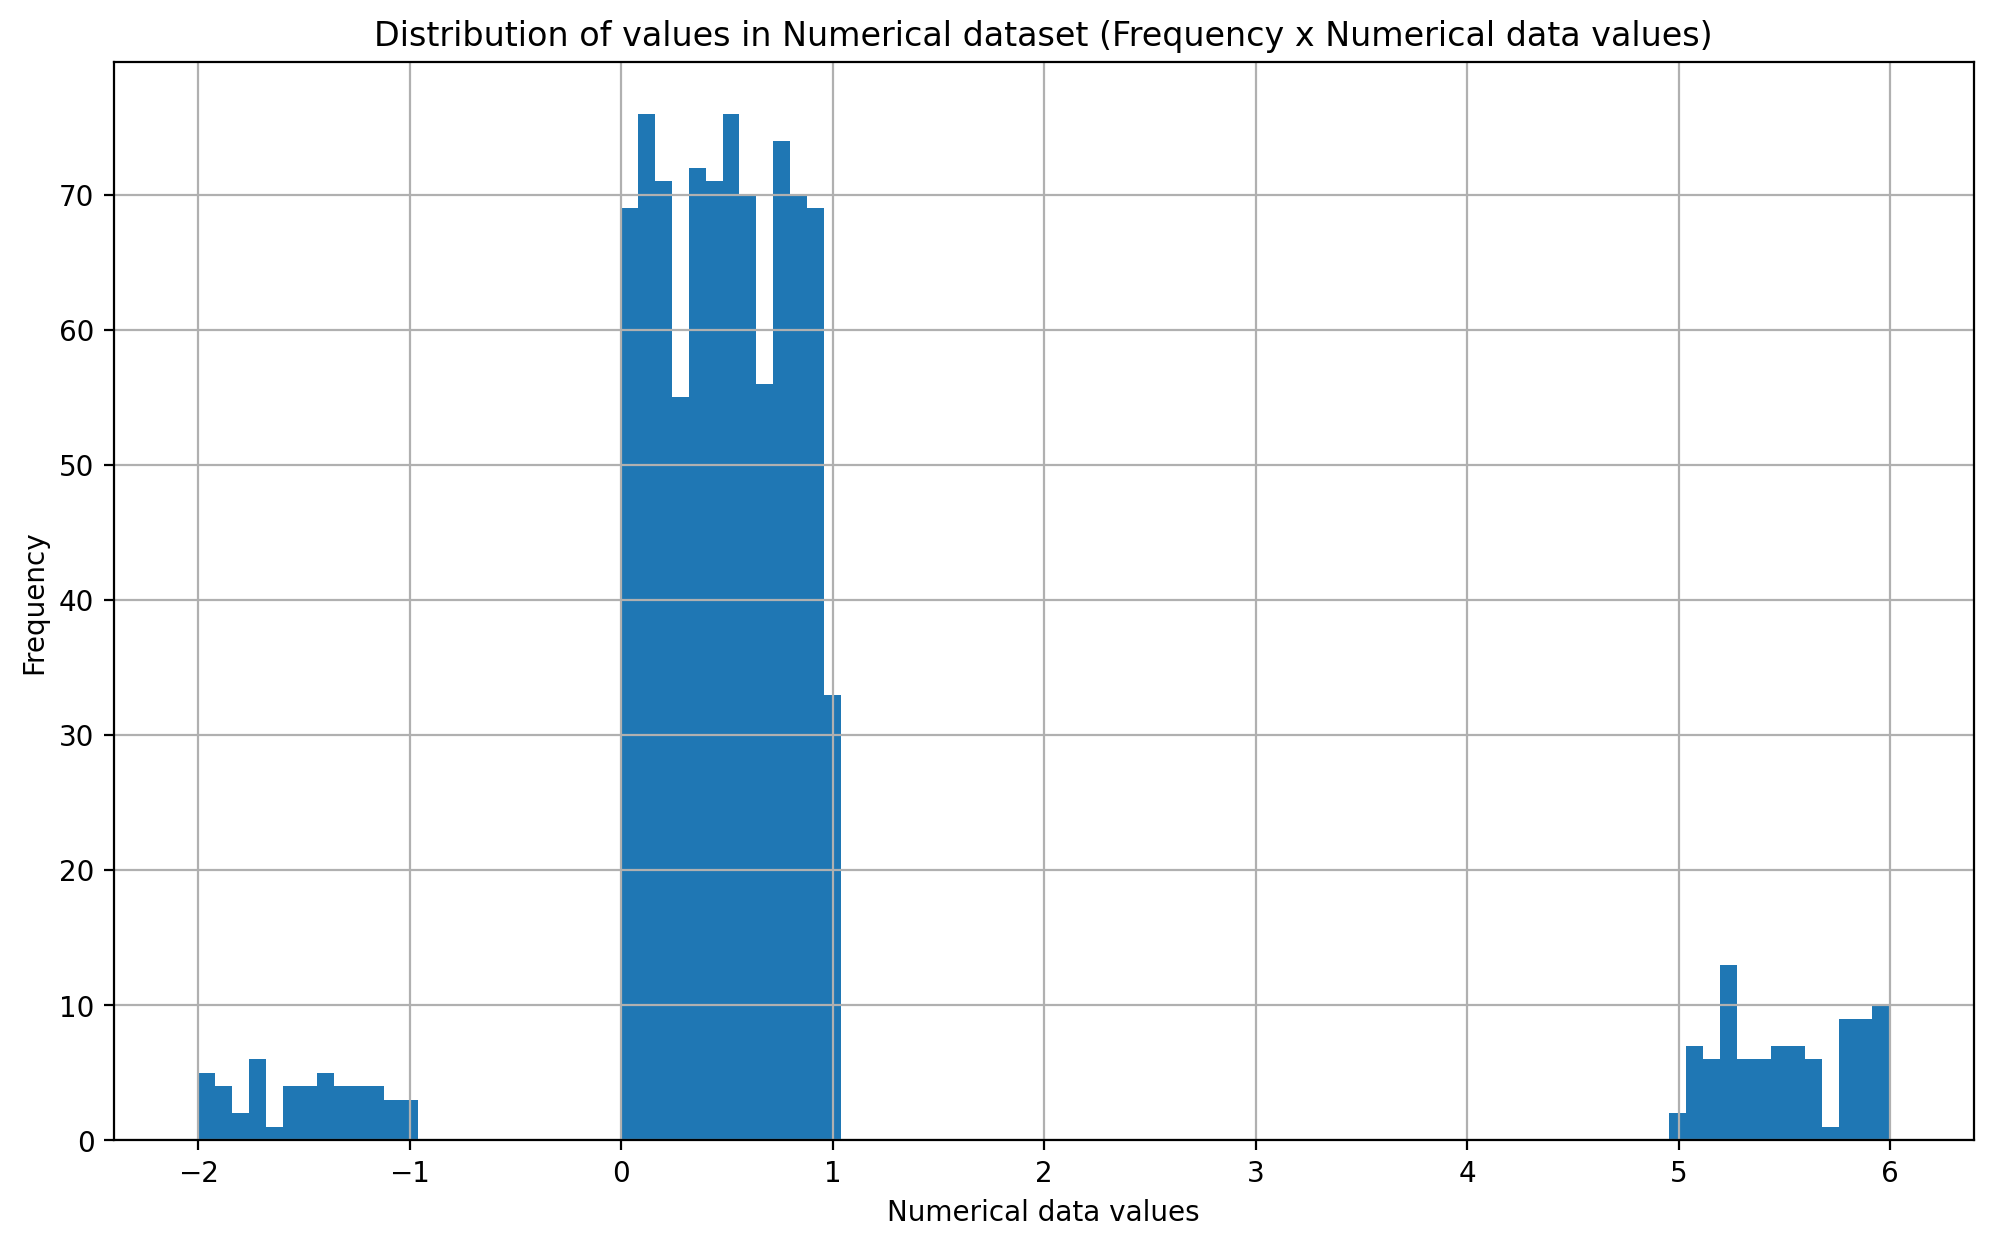

In [3]:
## Plot the histogram with 100 bins.

# YOUR CODE HERE 

#plotting histogram with 100 bins

df.hist(bins=100)

plt.xlabel("Numerical data values")
plt.ylabel("Frequency")
plt.title("Distribution of values in Numerical dataset (Frequency x Numerical data values)")

In [4]:
## There are values which are not valid. All values: should be positive and should also be less that 1 


# YOUR CODE HERE 

#new_df_invalid = df[(df['x']<0) & (df['x']>1)]
#new_df_invalid

new_df_values = df[(df>0) & (df<1)]
new_df_values.head()


,x
0,0.082365
1,0.850965
2,0.404772
3,0.023906
4,0.937930


Text(0.5, 1.0, 'Distribution of values in Numerical dataset (Frequency x Numerical data values)')

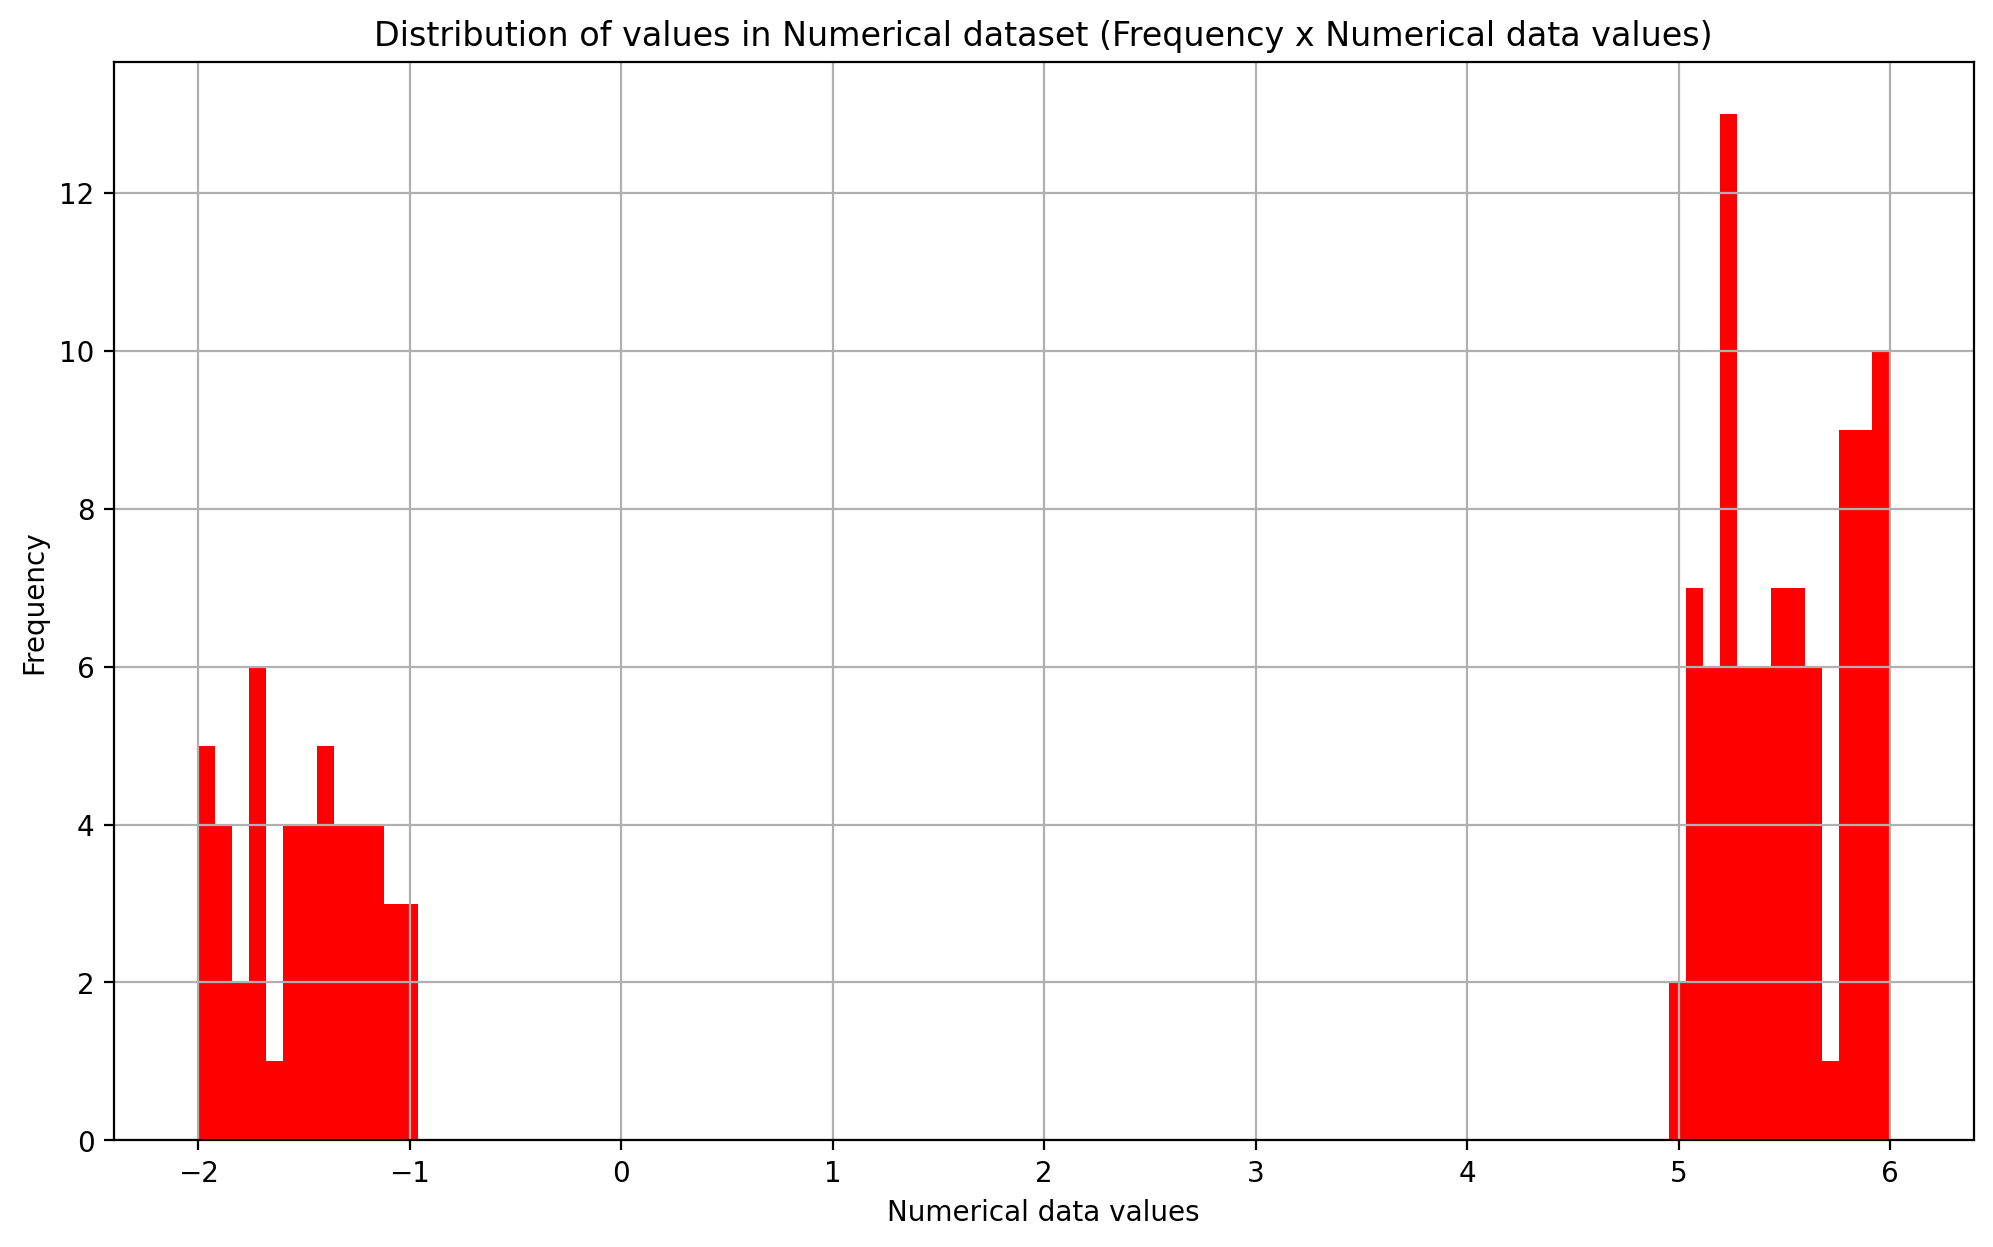

In [5]:
## Plot the histogram without the valid values.

# YOUR CODE HERE 

new_df_invalid = df[(df<0) | (df>1)]
new_df_invalid.head()

invalid_no_null = new_df_invalid.dropna()
invalid_no_null.head()

invalid_no_null.hist(bins = 100, color='red')

plt.xlabel("Numerical data values")
plt.ylabel("Frequency")
plt.title("Distribution of values in Numerical dataset (Frequency x Numerical data values)")

In [6]:
## For all non-valid values, insert the default value 0.5

# YOUR ANSWER BELOW

default_value = 0.5
df_default_value = df.applymap(lambda
x: default_value if x<0 or x>1 else
x)

df_default_value.head()

,x
0,0.082365
1,0.850965
2,0.404772
3,0.023906
4,0.937930


Text(0.5, 1.0, 'Distribution of values in Numerical dataset (Frequency x Numerical data values)')

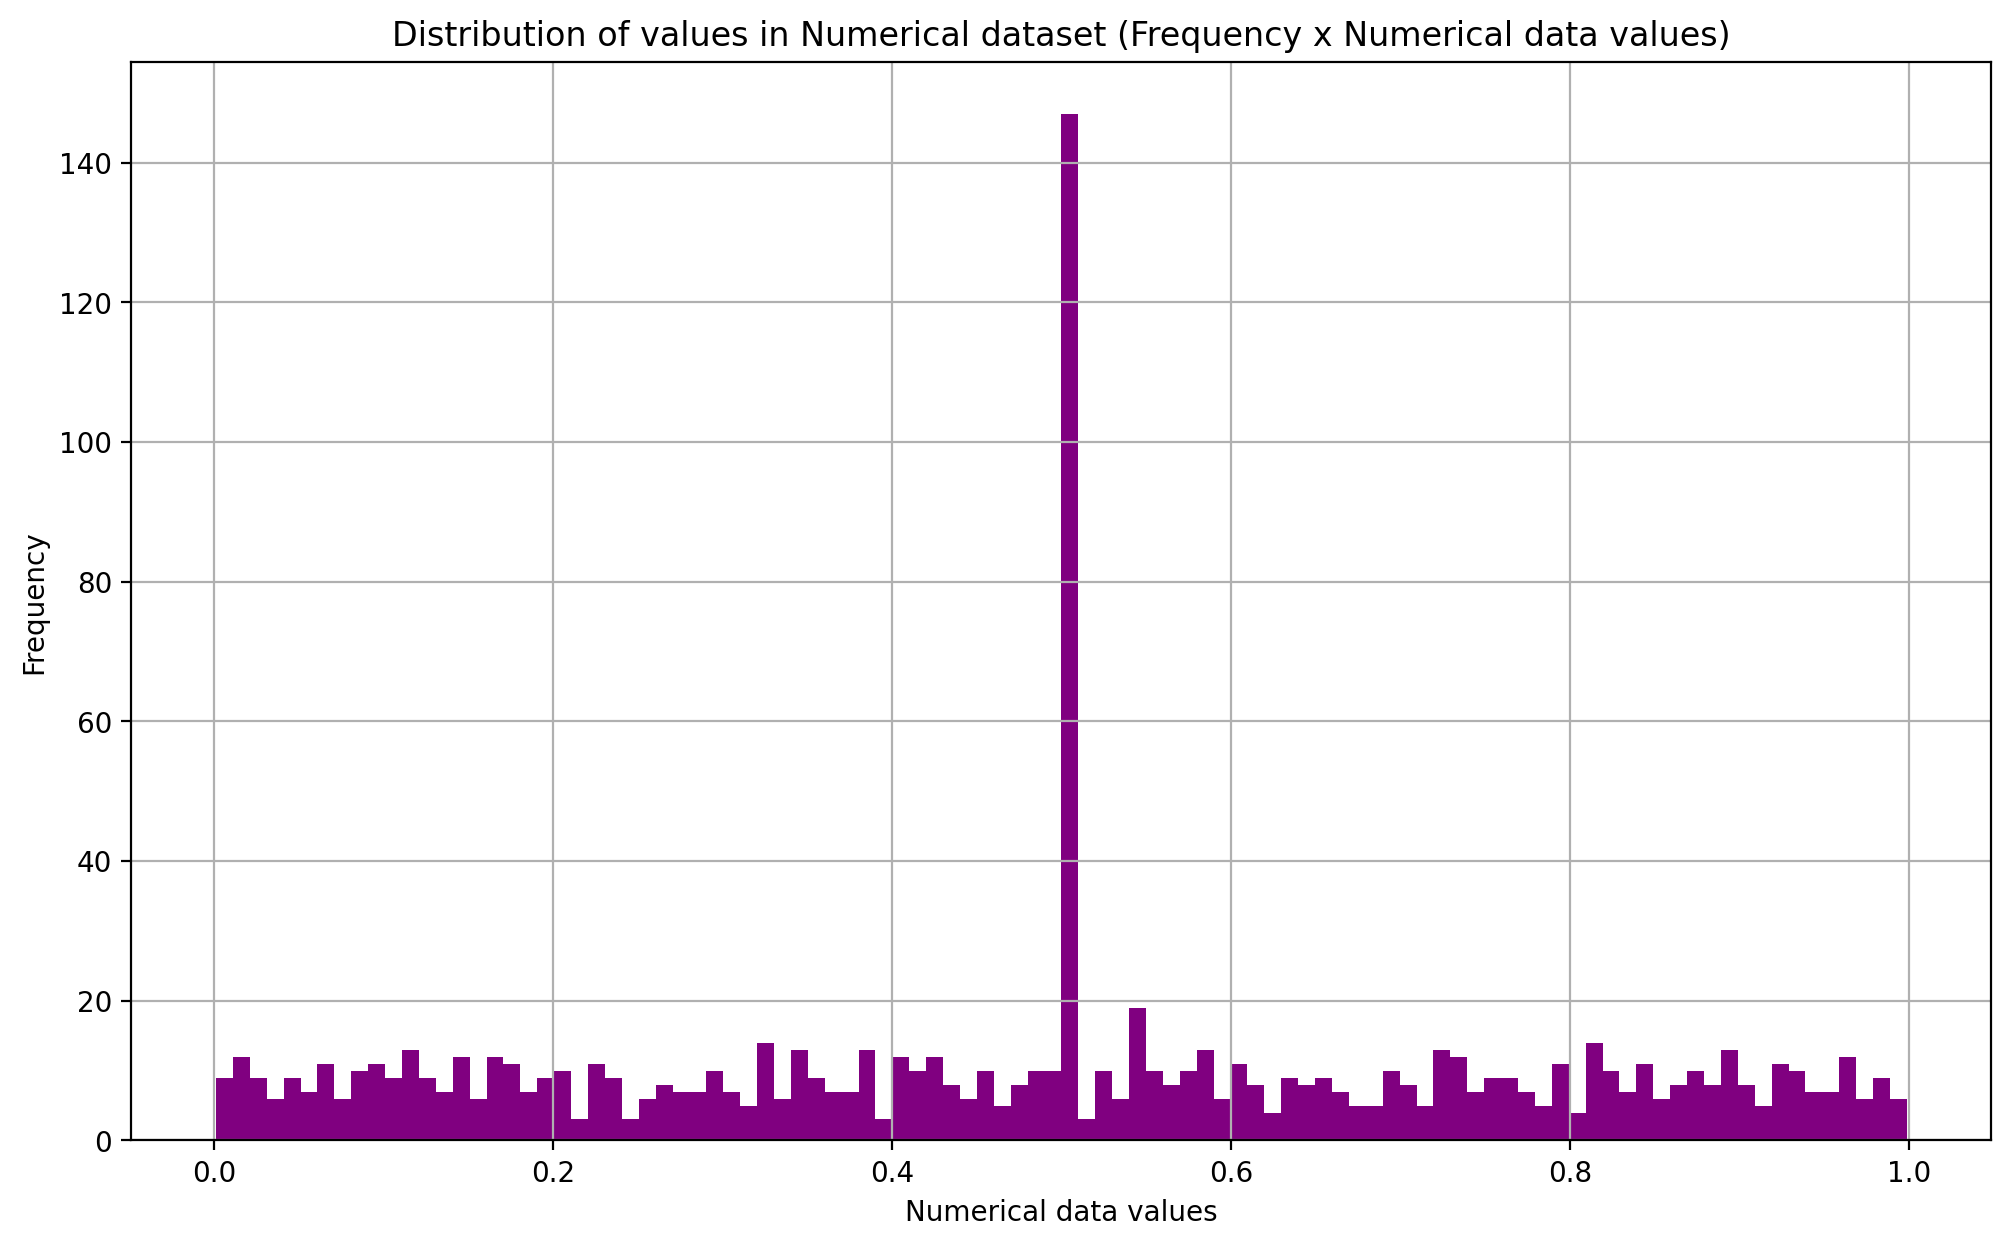

In [7]:
## Plot the histogram again.

# YOUR ANSWER BELOW 

df_default_value.hist(bins=100, color = 'purple')

plt.xlabel("Numerical data values")
plt.ylabel("Frequency")
plt.title("Distribution of values in Numerical dataset (Frequency x Numerical data values)")

In [8]:
## Should the non-valid values be included? Please give a short justification.

# YOUR ANSWER BELOW 



Write the difference here:

Yes, it should be included as over 140 data points are considered non\-valid and that contributes to a large % of the dataset. If they are not included they may lead to the dataset becoming skewed and therefore not valid. Although, it introduces noise and outliers. While these values are not necessarily errors, excluding them may enhance clarity and interpretability in visualisations. By replacing non\-valid values with a default, it indicates that certain data points fall outside the expected range, affecting a large % of the dataset. This it helps maintain clarity.


In [9]:
import pandas as pd

# YOUR CODE HERE
df_us = pd.read_csv("US_primary.csv")
df_us[['state', 'state_abbreviation', 'county', 'fips', 'party', 'candidate', 'votes', 'fraction_votes']] = df_us['state;state_abbreviation;county;fips;party;candidate;votes;fraction_votes'].str.split(';', expand=True)
df_us.drop(columns=['state;state_abbreviation;county;fips;party;candidate;votes;fraction_votes'], inplace=True)

df_us.head()

,state,state_abbreviation,county,fips,party,candidate,votes,fraction_votes
0,Vermont,VT,Sutton,95000197,Republican,John Kasich,20,0.22699999999999998
1,Vermont,VT,Tunbridge,95000204,Republican,John Kasich,36,0.319
2,Vermont,VT,Weathersfield,95000220,Republican,Ted Cruz,46,0.111
3,Vermont,VT,Weston,95000228,Republican,John Kasich,32,0.47100000000000003
4,Vermont,VT,Whiting,95000233,Republican,Ben Carson,0,0.0


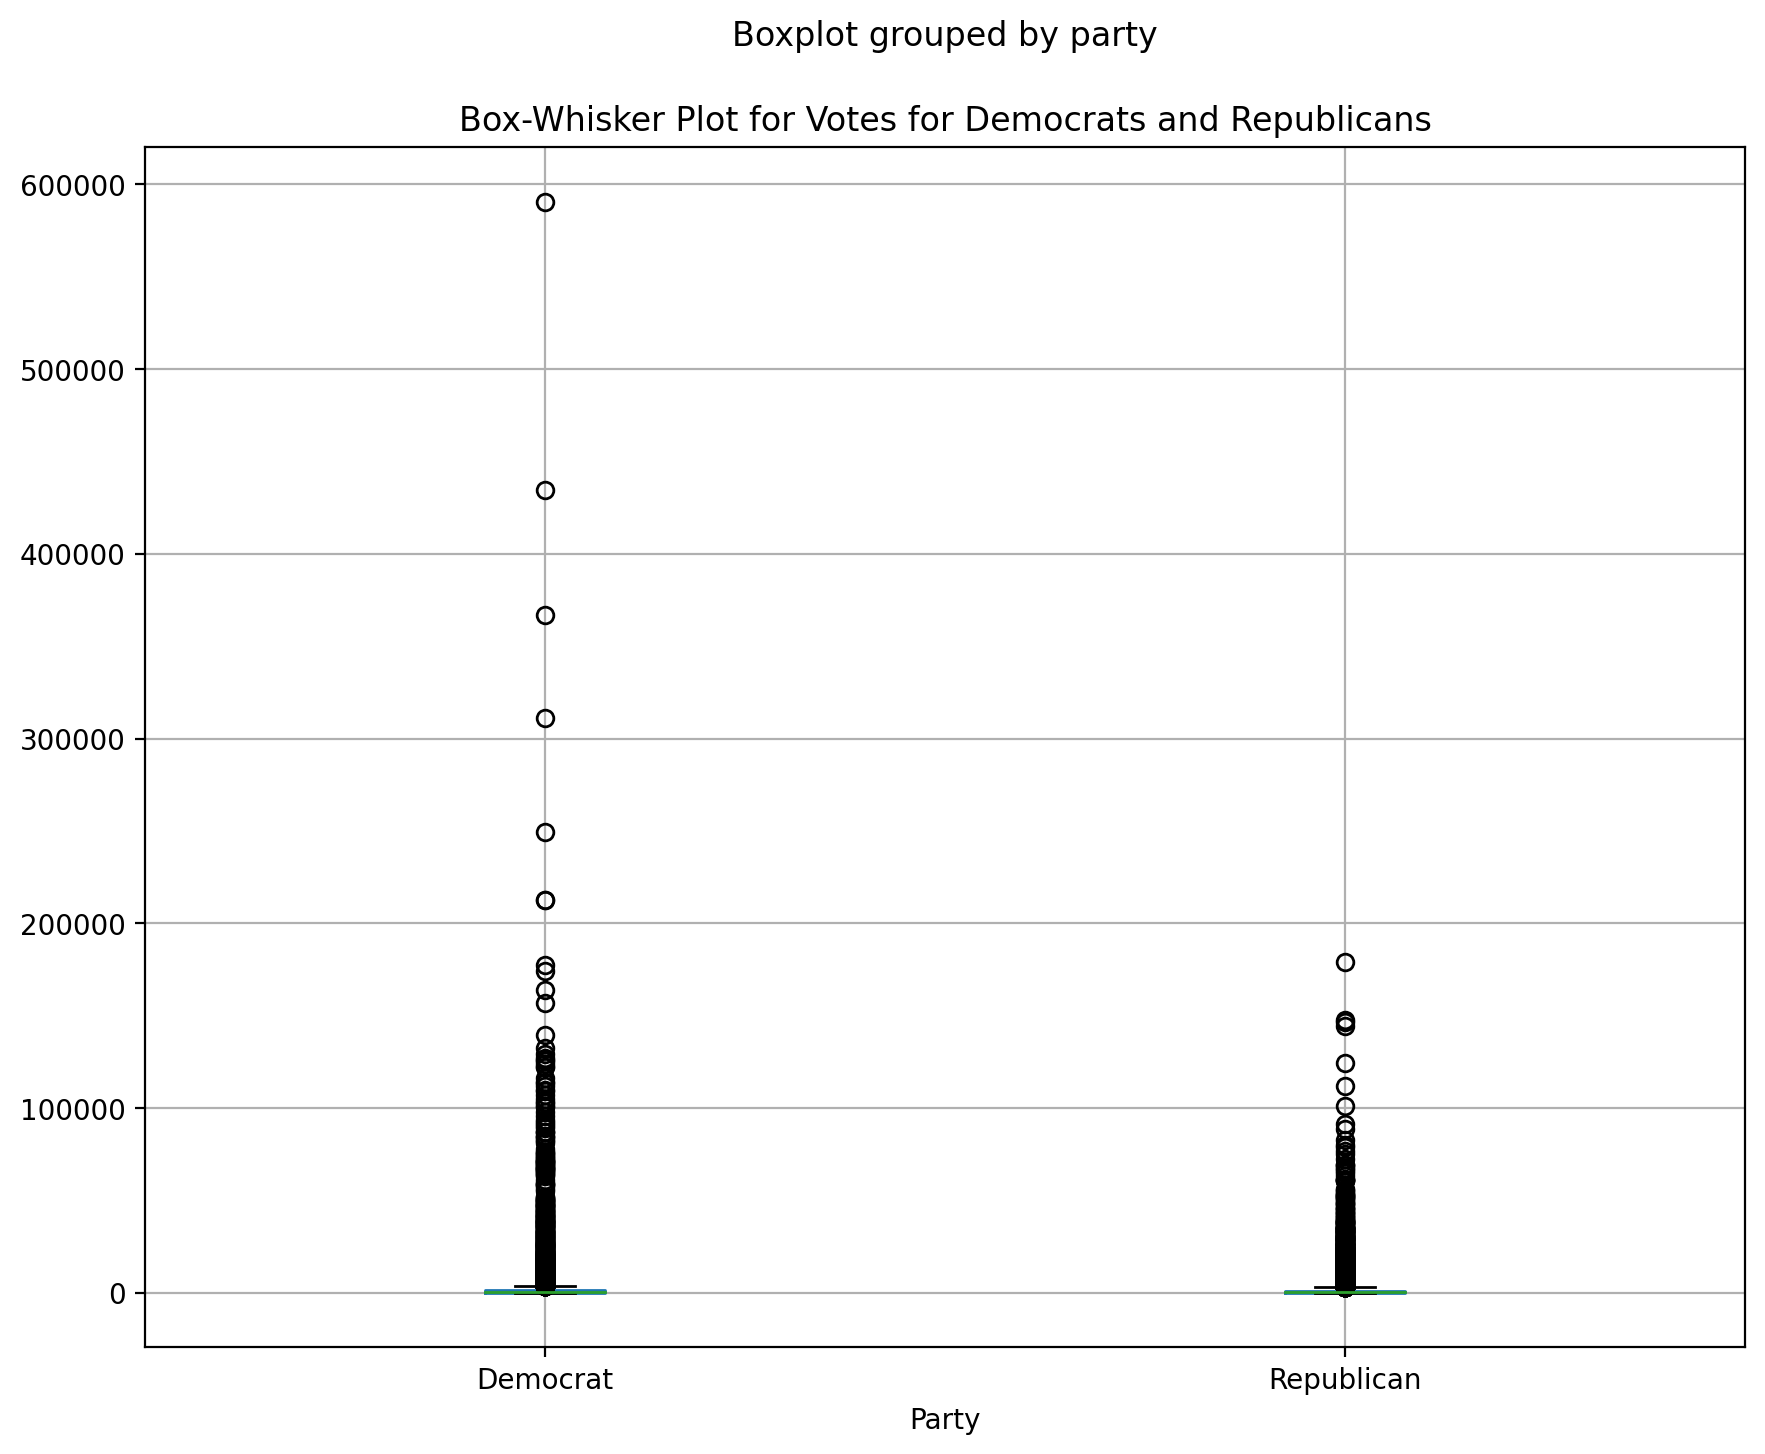

In [10]:
## Create a box-whisker plot for votes for Democrats and Republicans for votes. 

# YOUR ANSWER BELOW 2

filtered_df_us = df_us[(df_us['party'] == 'Democrat') | (df_us['party'] == 'Republican')]

#filtered_df_us = df_us[df_us['party'].isin(['Democrat', 'Republican'])]

filtered_df_us['votes'] = pd.to_numeric(filtered_df_us['votes'], errors='coerce')

filtered_df_us.boxplot(column='votes', by='party', figsize=(10, 8))
plt.title('Box-Whisker Plot for Votes for Democrats and Republicans')
plt.xlabel('Party')
plt.show()

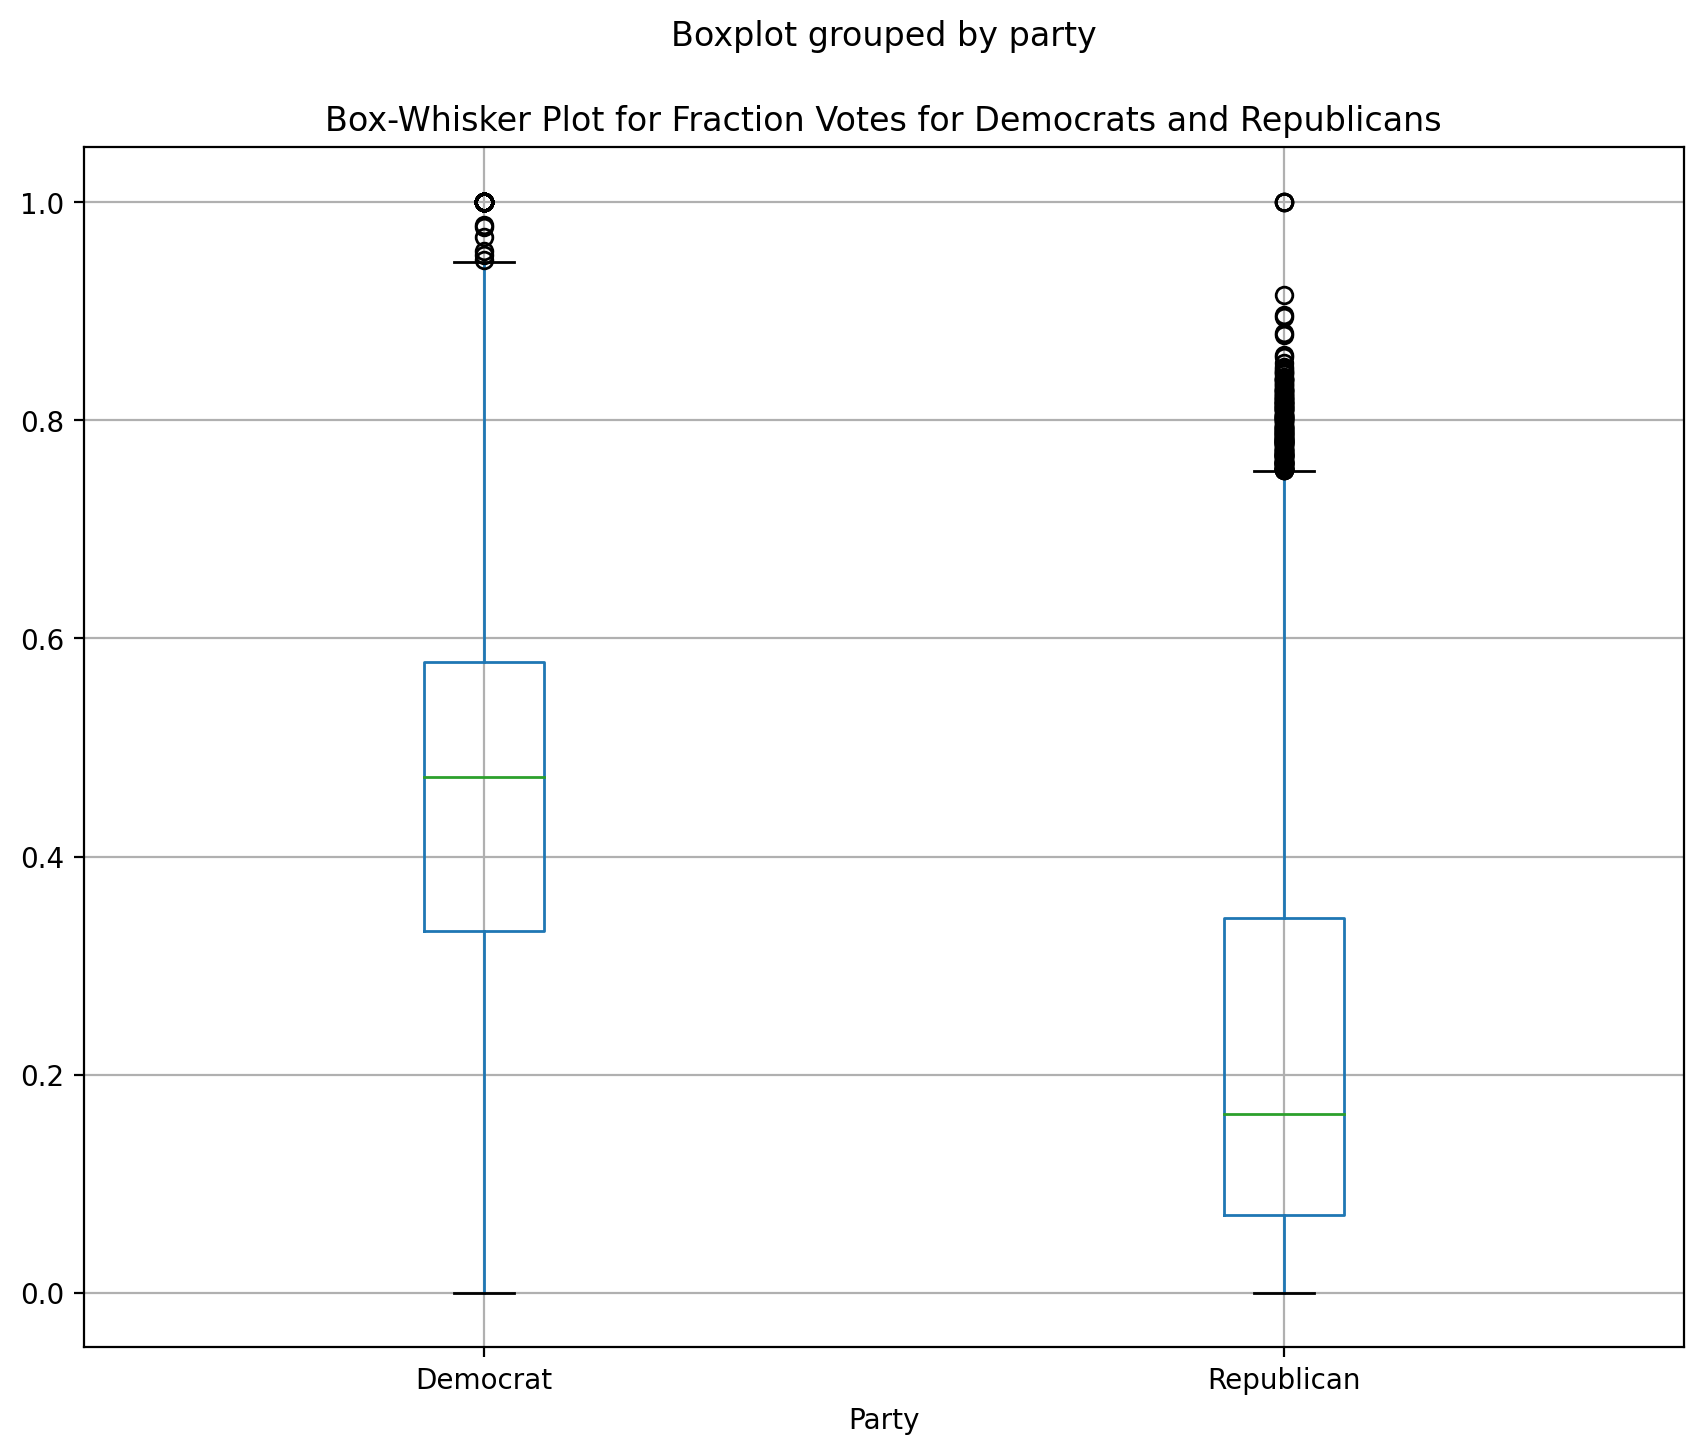

In [11]:
## Create a box-whisker plot for votes for Democrats and Republicans for fraction votes. 
## What is the main difference between the plots (and what can we say about the distribution)? 

# YOUR ANSWER BELOW 

filtered_df_us = df_us[(df_us['party'] == 'Democrat') | (df_us['party'] == 'Republican')]

#filtered_df_us = df_us[df_us['party'].isin(['Democrat', 'Republican'])]

filtered_df_us['fraction_votes'] = pd.to_numeric(filtered_df_us['fraction_votes'], errors='coerce')

filtered_df_us.boxplot(column='fraction_votes', by='party', figsize=(10, 8))
plt.title('Box-Whisker Plot for Fraction Votes for Democrats and Republicans')
plt.xlabel('Party')
plt.show()

Write your answer here:

The fraction votes has less datapoints than the regular votes box plot, because of this it is easier to distinguish the distribution of datapoints on the fraction votes box plot than it is on the normal votes box plot. Furthermore, there is a wider range of values on the normal box plot this allows for a trend within the data to be easily identified as well as obvious outliers being more easily identifiable, for example on the normal votes box plot it shows that a democrat had received over 60,000 votes which is an extremely high for in comparison to the rest of the democrats, this will help identify trends within the dataset.

Also, the normal dataset seems to be squeezed together which means its harder to identify specific points as well as areas such as the median in comparison to the fraction votes where the median is easily identifiable, it is also harder to identify the quartiles \(1st and 3rd\) as well the interquartile range of the normal votes box plot where as it is easier to identify the quartiles as well as the interquartile range in the fraction votes.


In [12]:
#Create a new DataFrame consisting only of rows which obtained more than 70% of the vote.

#-----------------------------------------------------------------------------------------------
df_more_than_70_percent = filtered_df_us[filtered_df_us['fraction_votes'] > 0.7]
df_more_than_70_percent.head()

,state,state_abbreviation,county,fips,party,candidate,votes,fraction_votes
10,Virginia,VA,Dinwiddie,51053,Democrat,Hillary Clinton,1935,0.833
54,Washington,WA,Snohomish,53061,Republican,Donald Trump,35474,0.752
57,Washington,WA,Yakima,53077,Republican,Donald Trump,14872,0.826
62,West Virginia,WV,Jackson,54035,Republican,Donald Trump,3585,0.757
67,West Virginia,WV,Randolph,54083,Republican,Donald Trump,2206,0.779


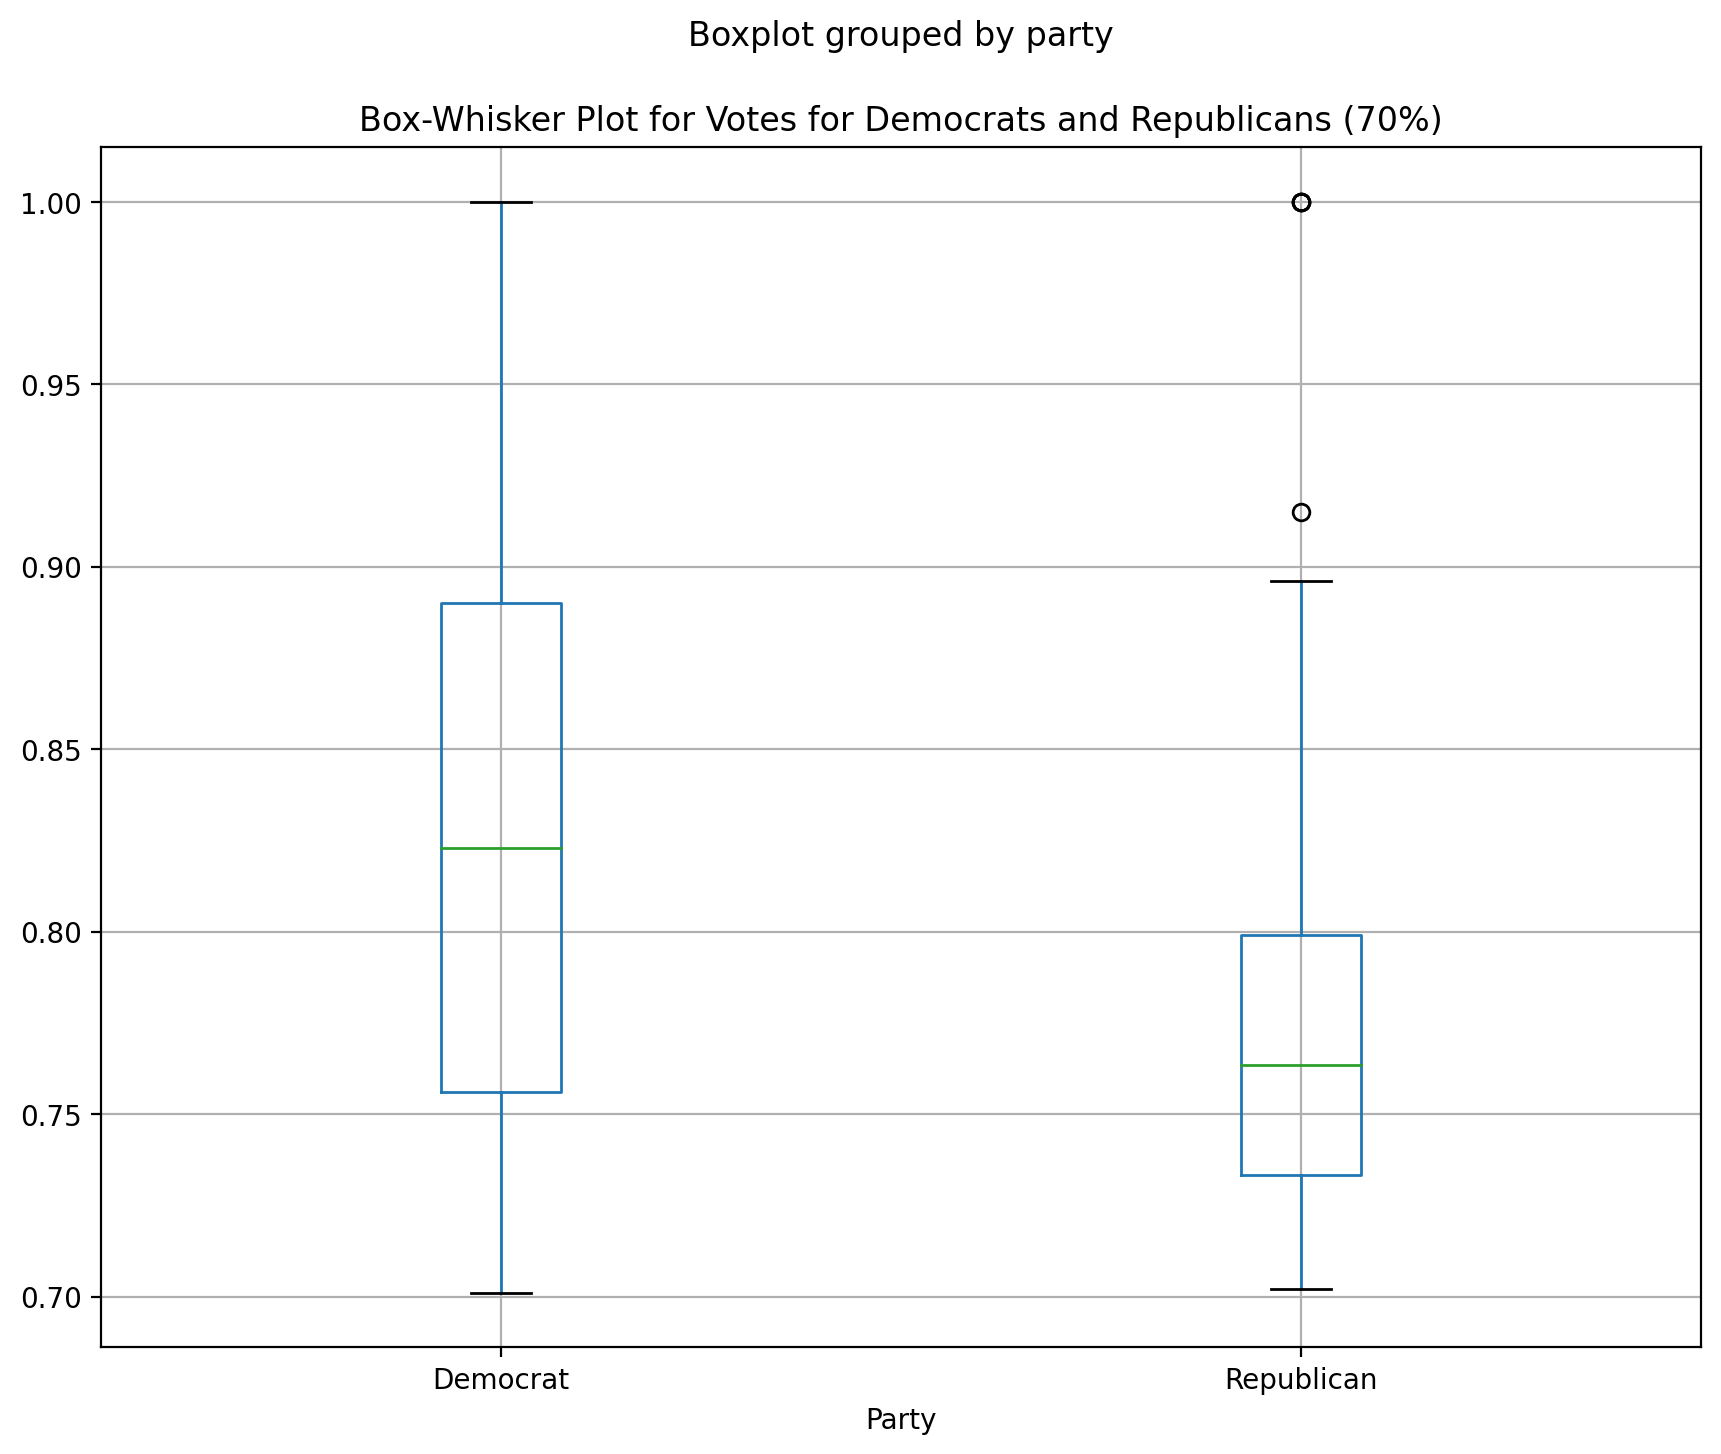

In [13]:
#Plot the box-whisker plot for this new DataFrame (again for votes). 
#Does this look similar or different? Can you explain what you are seeing?

df_more_than_70_percent.boxplot(column = 'fraction_votes', by='party', figsize=(10,8))
plt.title('Box-Whisker Plot for Votes for Democrats and Republicans (70%)')
plt.xlabel('Party')
plt.show()

Does this look similar or different? Can you explain what you are seeing?

The plots have less outliers with the only outliers being on the republican side while the democrat side has non, there is a wider range on the maximum and minimum values with the repulican side now have a maximum \(q3x1.5\) being closer to 0.9 whereas in the previous box plot it was closer to 0.8, showing a change in the box plot. The median on both plots has altered and can now be found in different places showing the middle value of each plot has changed, the interquartile range for the republican boxplot has decreased in size whereas the interquartile range for the democrat box plot has increased.



In [14]:
## Question 3 (as presented in the relevant pdf file)

# YOUR CODE AND ANSWER HERE (you can add more cells for your answer if needed)

x_values = [0,1,2,3,4,5,6,7,8]
y_values = []
for i in x_values:
    if i < 2:
        y_values.append(-i)
    elif i >= 2 and i < 6:
        y_values.append(i-4)
    else:
        y_values.append(-i + 8)
        
y_values

[0, -1, -2, -1, 0, 1, 2, 1, 0]

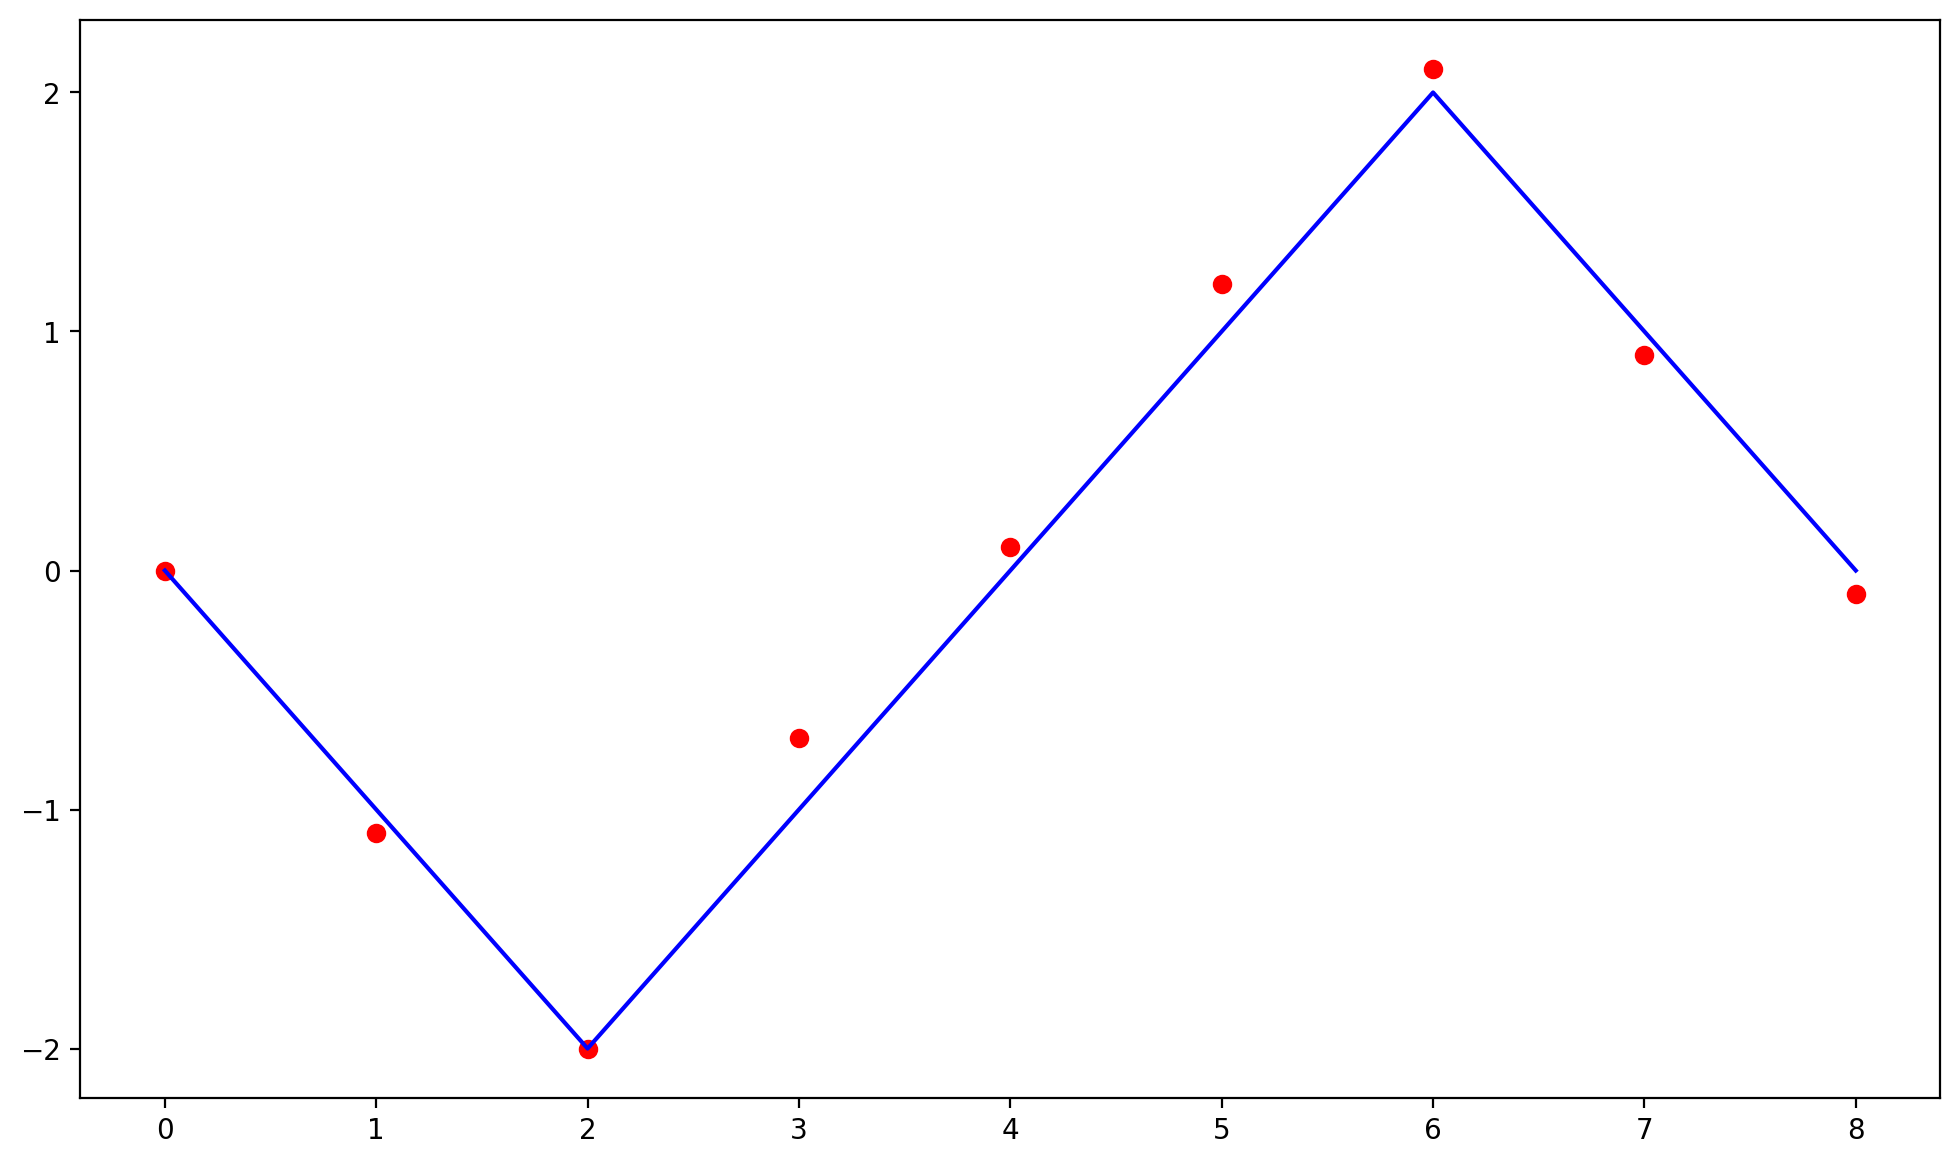

In [15]:
fx = [0, -1.1 , -2, -0.7, 0.1, 1.2, 2.1, 0.9, -0.1]
plt.scatter(x_values,fx, color='red')
plt.plot(y_values, "blue")
plt.show()

The scatter plot provides an effective visual depiction of how well the model captures the underlying patterns in the dataset. Looking at the plot, you will see that the actual data points and the predicted values are remarkably close to each other. These points exhibit tight clustering, which suggests a high degree of accuracy and the model's ability to capture the underlying relationships in the data.

The fact that residuals, between expected and actual values, seem small supports the model's validity. The model's intended overlay on the scatter plot highlights how well it matches the dataset, giving an understandable and straightforward representation of the predictive accuracy.

